In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import bjontegaard as bd

pd.set_option('display.max_columns', None)
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['axes.labelsize'] = 22

### My results (AHT-DCT)

In [17]:
results_df = pd.read_csv("results.csv", header=0)
results_df = results_df[results_df["bpp"] > 0.1]
results_df = results_df[results_df["lmbda"] != 0.6225]

results_df.tail()

,arch,model,lmbda,test_date,bpp,psnr_iq,msssim_iq,psnr_amp,sqnr_amp,msssim_amp,mae_phase,mse_nrcs,enc_time,dec_time,total_kmac_per_px,enc_kmac_per_px,dec_kmac_per_px,ga_kmac_per_px,ha_kmac_per_px,gs_kmac_per_px,hs_kmac_per_px,total_params,energy_1,energy_2,energy_3,energy_4
8,AHT,lmbda0.0035,0.0035,20260420,1.180716,29.678772,0.974401,27.019819,14.708034,0.964156,0.471662,0.001566,0.006218,0.007455,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,5.656303,3.013303,1.618914,1.287820
9,AHT,lmbda0.0067,0.0067,20260420,1.508412,32.186926,0.987829,29.549334,17.670773,0.982037,0.343355,0.001073,0.006200,0.007542,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,15.453101,7.112835,3.841097,3.211034
10,AHT,lmbda0.013,0.0130,20260420,1.819167,33.798535,0.993604,31.211693,19.897261,0.989171,0.306024,0.000899,0.006213,0.007591,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,50.198725,18.334217,8.539393,7.446158
11,AHT,lmbda0.025,0.0250,20260420,2.094561,34.717432,0.996137,32.237846,21.546754,0.992575,0.259936,0.000800,0.006301,0.007812,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,134.372346,43.977658,17.729829,23.895027
12,AHT,lmbda0.0483,0.0483,20260420,2.349029,35.313943,0.997257,32.900541,22.863387,0.994292,0.208875,0.000761,0.006280,0.007971,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,324.180513,92.325415,40.037960,59.915752


In [18]:
results_highres_df = pd.read_csv("results_highres.csv", header=0).sort_values(["arch", "model", "lmbda"])
results_highres_df = results_highres_df[results_highres_df["bpp"] > 0.1]
results_highres_df = results_highres_df[results_highres_df["lmbda"] != 0.6225]

results_highres_df.head()

,arch,model,lmbda,test_date,bpp,psnr_iq,msssim_iq,psnr_amp,sqnr_amp,msssim_amp,mae_phase,mse_nrcs,enc_time,dec_time,total_kmac_per_px,enc_kmac_per_px,dec_kmac_per_px,ga_kmac_per_px,ha_kmac_per_px,gs_kmac_per_px,hs_kmac_per_px,total_params,energy_1,energy_2,energy_3,energy_4
35,AHT,lmbda0.0018,0.0018,20260420,0.947861,24.789393,0.945306,22.334571,12.344555,0.921259,0.600849,0.004409,0.277170,0.070719,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,1.807820,1.405797,1.001060,0.507439
36,AHT,lmbda0.0035,0.0035,20260420,1.332535,27.866389,0.978065,25.498639,15.905751,0.965961,0.389107,0.002394,0.263426,0.072493,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,8.436717,3.993659,2.130558,1.712216
37,AHT,lmbda0.0067,0.0067,20260420,1.661057,29.876338,0.989030,27.611407,18.625248,0.981686,0.289467,0.001705,0.274862,0.073011,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,23.743351,9.543767,4.879025,4.302050
38,AHT,lmbda0.013,0.0130,20260420,1.987534,30.815164,0.993959,28.668565,20.567801,0.987653,0.266950,0.001530,0.267775,0.075932,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,79.182999,24.426659,11.303761,10.780755
39,AHT,lmbda0.025,0.0250,20260420,2.275345,31.362702,0.996077,29.389894,21.943230,0.991039,0.233013,0.001374,0.269618,0.079085,18.9395,10.4795,8.46,10.0,0.4795,6.64,1.82,3501266,208.636505,59.585320,24.791403,37.407974


In [19]:
results_bench_df = pd.read_csv("results_bench.csv", header=0)
results_bench_df = results_bench_df[results_bench_df["bpp"] > 0.1]

results_bench_df.tail()

,codec,dataset,date,qp,bpp,mse_iq,psnr_iq,mse_amp,psnr_amp,sqnr_amp,mae_phase,mse_nrcs,encoding_time,decoding_time
19,HM,val,2026-04-19,42,0.545761,0.005061,23.064476,0.011476,19.449068,6.670573,1.277469,0.005436,0.927856,0.334473
20,VTM,val,2026-04-19,27,2.261140,0.000193,37.409144,0.000365,34.460425,21.540961,0.260495,0.000170,21.123255,0.193232
21,VTM,val,2026-04-19,32,1.651556,0.000521,32.898731,0.001014,30.004235,17.093213,0.422870,0.000495,19.309664,0.197448
22,VTM,val,2026-04-19,37,1.073627,0.001547,28.167408,0.003062,25.193399,12.305523,0.727657,0.001476,17.135215,0.191661
23,VTM,val,2026-04-19,42,0.555657,0.004393,23.659563,0.010327,19.920020,7.108178,1.237642,0.004218,13.473147,0.193471


# Ablation Study: Group Size

Model: g1 | BD-Rate: 0.00%
Model: g2 | BD-Rate: -0.21%
Model: g4 | BD-Rate: 1.11%
Model: g6 | BD-Rate: 1.87%
Model: g8 | BD-Rate: -0.14%
Model: g16 | BD-Rate: 0.72%
Model: g32 | BD-Rate: 1.52%


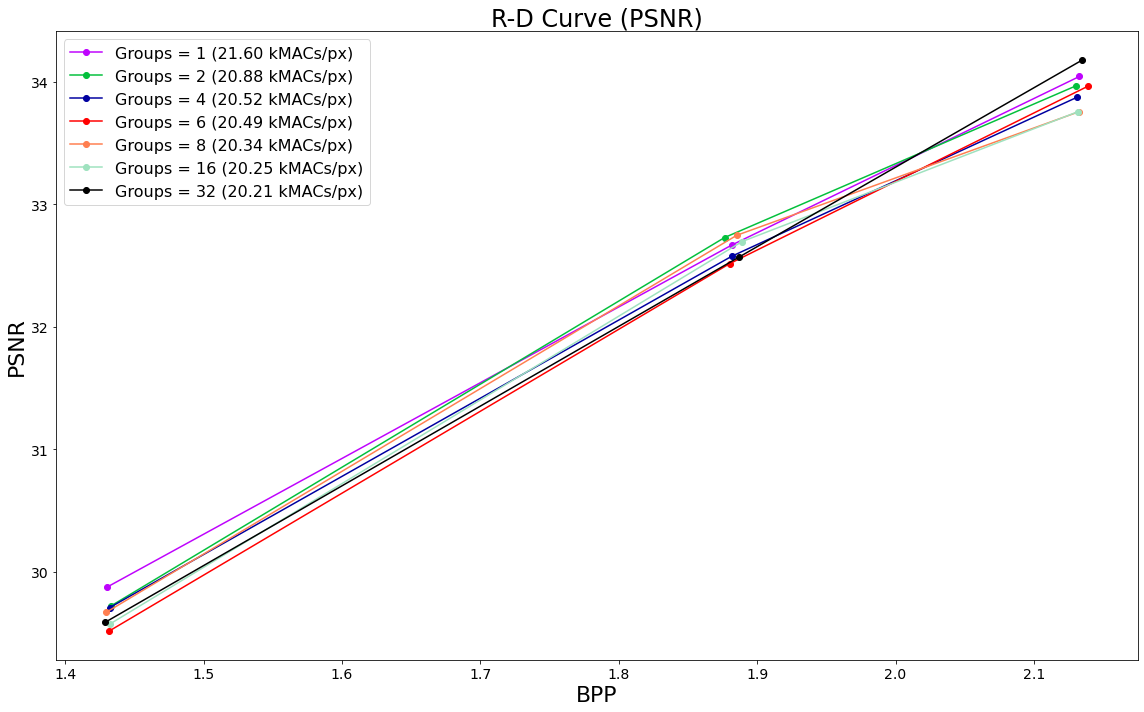

In [9]:
rd_data = {}
colors = ["#BE03FD", "#03C03C", "#0000A0", "#FF0000", "#FF7F50", "#9FE2BF"]
for model in ["g1", "g2", "g4", "g6", "g8", "g16", "g32"]:
    data = results_highres_df[(results_highres_df["arch"] == "PACTtest") & (results_highres_df["model"] == f"{model}alpha1.0")]
    rd_data[model] = {
        "bpp": data["bpp"].round(4).tolist(),
        "psnr": data["psnr_iq"].round(4).tolist(),
        "kmacs": data["total_kmac_per_px"].round(4).tolist()[0],
        "color": colors.pop(0) if colors else "#000000",
        "marker": "o",
        "linestyle": "solid",
    }

legend_labels = {
    "g1": f"Groups = 1 ({rd_data['g1']['kmacs']:.2f} kMACs/px)",
    "g2": f"Groups = 2 ({rd_data['g2']['kmacs']:.2f} kMACs/px)",
    "g4": f"Groups = 4 ({rd_data['g4']['kmacs']:.2f} kMACs/px)",
    "g6": f"Groups = 6 ({rd_data['g6']['kmacs']:.2f} kMACs/px)",
    "g8": f"Groups = 8 ({rd_data['g8']['kmacs']:.2f} kMACs/px)",
    "g16": f"Groups = 16 ({rd_data['g16']['kmacs']:.2f} kMACs/px)",
    "g32": f"Groups = 32 ({rd_data['g32']['kmacs']:.2f} kMACs/px)",
}

for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    psnr_test = rd_data[model]["psnr"]
    rate_anchor = rd_data["g1"]["bpp"]
    psnr_anchor = rd_data["g1"]["psnr"]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor,
        psnr_anchor,
        rate_test,
        psnr_test,
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_title("R-D Curve (PSNR)", fontsize=24)

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    ax.plot(bpp, psnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])

ax.set_xlabel("BPP", fontsize=22)
ax.set_ylabel("PSNR", fontsize=22)
ax.legend([legend_labels[key] for key in rd_data.keys()], fontsize=16)
plt.tight_layout()
plt.show()

# Ablation Study: Fine-Tuning

PSNR BD-RATE
Model: vvc | BD-Rate: 14.24%
Model: pactiq | BD-Rate: 0.00%
Model: pactamp | BD-Rate: -0.47%

SQNR BD-RATE
Model: vvc | BD-Rate: 20.75%
Model: pactiq | BD-Rate: 0.00%
Model: pactamp | BD-Rate: -1.12%

MAPE BD-RATE
Model: vvc | BD-Rate: 28.33%
Model: pactiq | BD-Rate: 0.00%
Model: pactamp | BD-Rate: -0.32%


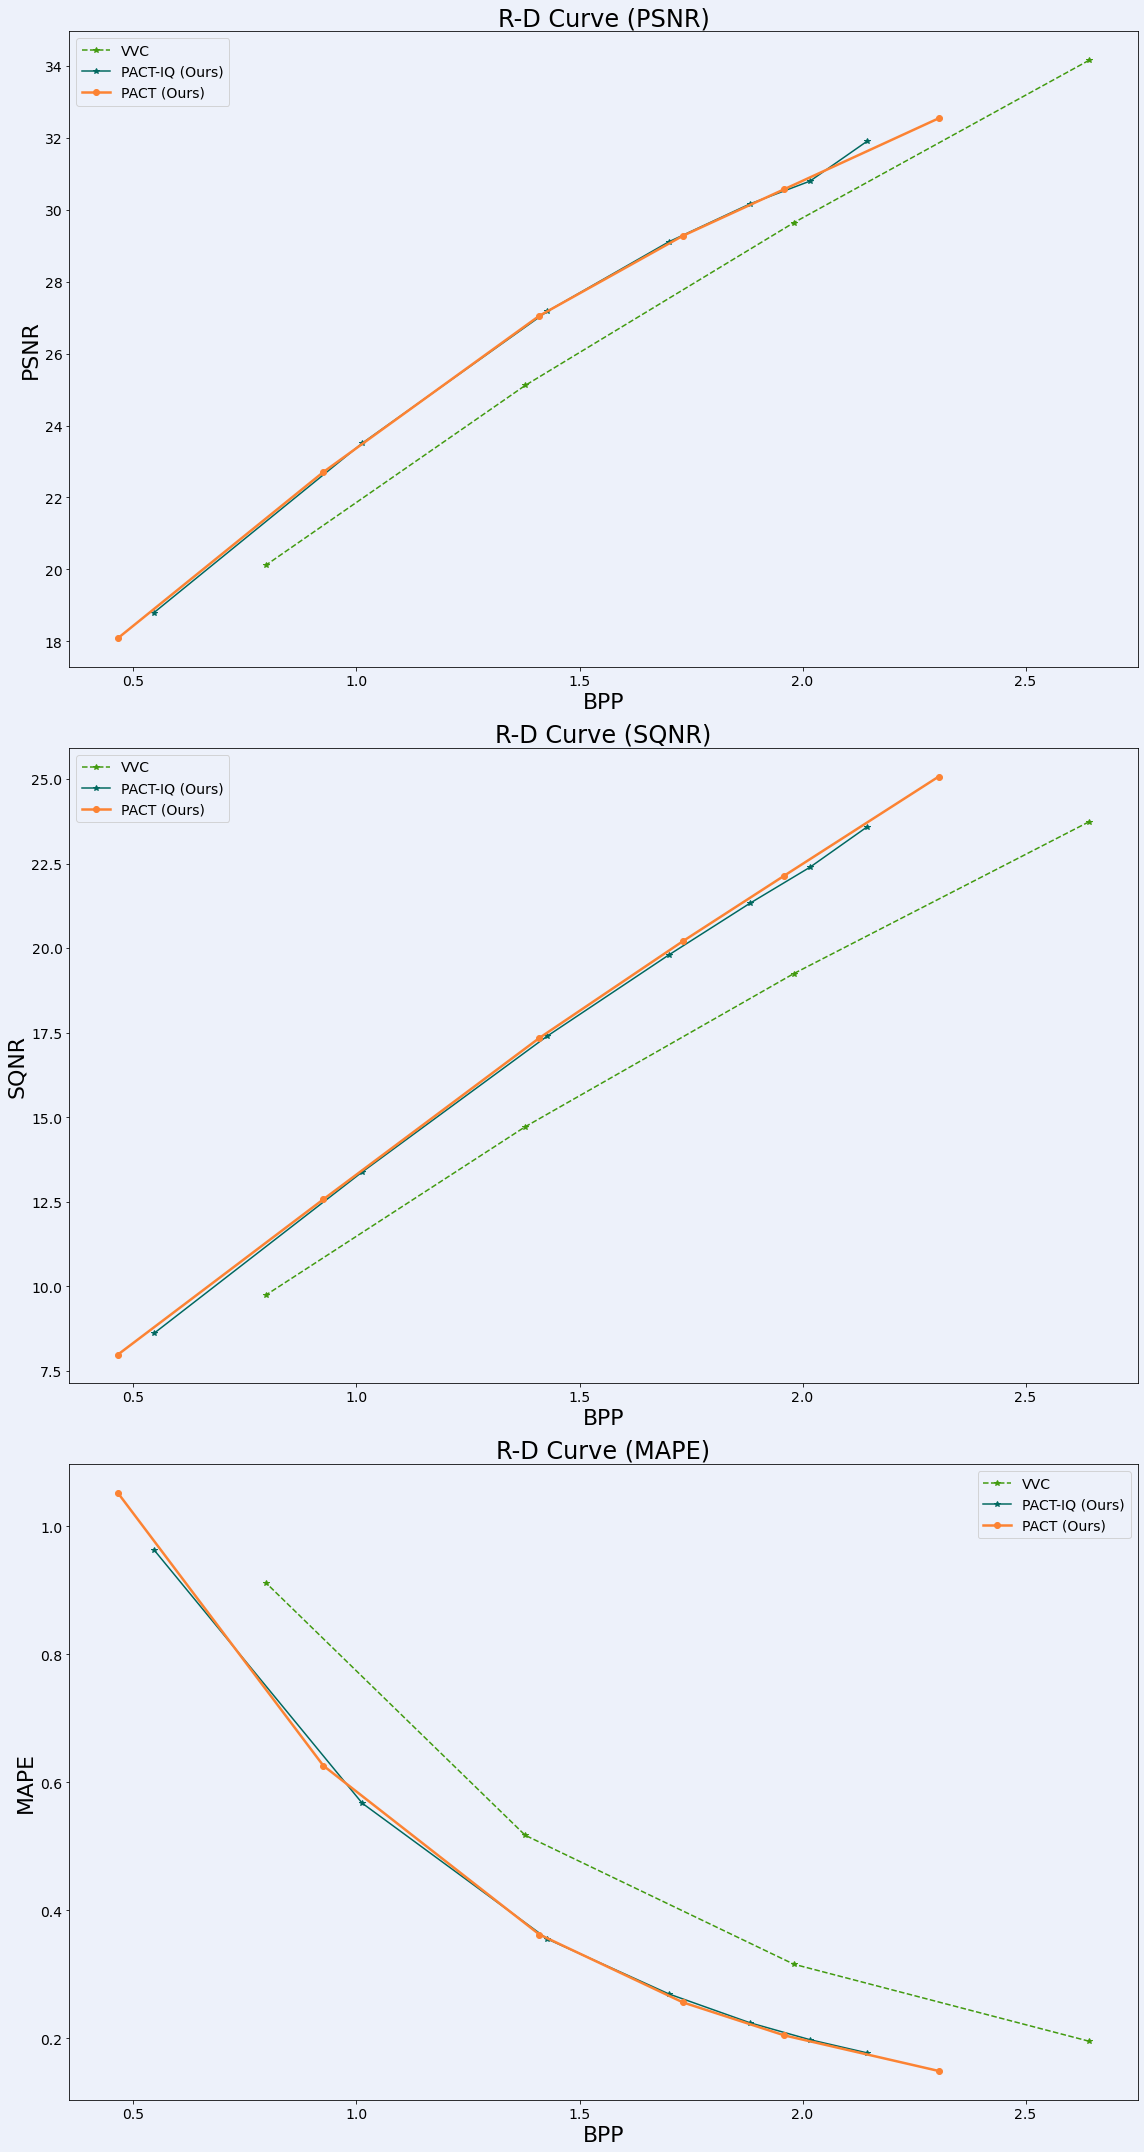

In [24]:
vvc_hr_data = results_bench_df[(results_bench_df["codec"] == "VTM") & (results_bench_df["dataset"] == "test")]
pactiq_hr_data = results_highres_df[(results_highres_df["arch"] == "PACT") & (results_highres_df["model"] == "g8alpha1.0")]
pactamp_hr_data = results_highres_df[(results_highres_df["arch"] == "PACT") & (results_highres_df["model"] == "g8alpha0.01")]

rd_data = {
    "vvc": {
        "bpp": vvc_hr_data["bpp"].round(4).tolist(),
        "psnr": vvc_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": vvc_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": vvc_hr_data["mae_phase"].round(4).tolist(),
        "color": "#419A0E",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
        "legend": "VVC",
    },
    "pactiq": {
        "bpp": pactiq_hr_data["bpp"].round(4).tolist(),
        "psnr": pactiq_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": pactiq_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": pactiq_hr_data["mae_phase"].round(4).tolist(),
        "color": "#00685f",
        "marker": "*",
        "linestyle": "solid",
        "linewidth": 1.5,
        "legend": "PACT-IQ (Ours)",
    },
    "pactamp": {
        "bpp": pactamp_hr_data["bpp"].round(4).tolist(),
        "psnr": pactamp_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": pactamp_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": pactamp_hr_data["mae_phase"].round(4).tolist(),
        "color": "#FC8333",
        "marker": "o",
        "linestyle": "solid",
        "linewidth": 2.5,
        "legend": "PACT (Ours)",
    },
}

# PSNR BD-Rate
print("PSNR BD-RATE")
for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    psnr_test = rd_data[model]["psnr"]
    rate_anchor = rd_data["pactiq"]["bpp"]
    psnr_anchor = rd_data["pactiq"]["psnr"]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor, 
        psnr_anchor, 
        rate_test, 
        psnr_test, 
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

# SQNR BD-Rate
print("\nSQNR BD-RATE")
for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    psnr_test = rd_data[model]["sqnr"]
    rate_anchor = rd_data["pactiq"]["bpp"]
    psnr_anchor = rd_data["pactiq"]["sqnr"]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor, 
        psnr_anchor, 
        rate_test, 
        psnr_test, 
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

# MAPE BD-Rate
print("\nMAPE BD-RATE")
for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    mape_test = [-x for x in rd_data[model]["mape"]]
    rate_anchor = rd_data["pactiq"]["bpp"]
    mape_anchor = [-x for x in rd_data["pactiq"]["mape"]]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor, 
        mape_anchor, 
        rate_test, 
        mape_test, 
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

# Make 3 subplots for PSNR, SQNR, and MAPE
fig, ax = plt.subplots(3, 1, figsize=(16, 30))
bg_color = "#edf1fa"

ax[0].set_title("R-D Curve (PSNR)", fontsize=24)
ax[1].set_title("R-D Curve (SQNR)", fontsize=24)
ax[2].set_title("R-D Curve (MAPE)", fontsize=24)

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    sqnr = rd_data[model]["sqnr"]
    mape = rd_data[model]["mape"]

    ax[0].plot(bpp, psnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])
    ax[1].plot(bpp, sqnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])
    ax[2].plot(bpp, mape, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])

ax[0].set_xlabel("BPP", fontsize=22)
ax[0].set_ylabel("PSNR", fontsize=22)
ax[0].legend([rd_data[key]["legend"] for key in rd_data.keys()], facecolor=bg_color)
ax[1].set_xlabel("BPP", fontsize=22)
ax[1].set_ylabel("SQNR", fontsize=22)
ax[1].legend([rd_data[key]["legend"] for key in rd_data.keys()], facecolor=bg_color)

# extent = ax[1].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
# fig.savefig("rd_sqnr.png", bbox_inches=extent)

ax[2].set_xlabel("BPP", fontsize=22)
ax[2].set_ylabel("MAPE", fontsize=22)
ax[2].legend([rd_data[key]["legend"] for key in rd_data.keys()], facecolor=bg_color)
fig.set_facecolor(bg_color)
ax[0].set_facecolor(bg_color)
ax[1].set_facecolor(bg_color)
ax[2].set_facecolor(bg_color)
plt.tight_layout()
plt.show()

# Benchmarking with G=8

### HR Data

SQNR BD-RATE
Model: jpeg2000 | BD-Rate: 52.01%
Model: hevc | BD-Rate: 8.28%
Model: vvc | BD-Rate: 0.00%
Model: elicdct | BD-Rate: -21.59%
Model: aht | BD-Rate: -10.64%
Model: pactamp | BD-Rate: -17.96%

MAPE BD-RATE
Model: jpeg2000 | BD-Rate: 69.88%
Model: hevc | BD-Rate: 8.05%
Model: vvc | BD-Rate: 0.00%
Model: elicdct | BD-Rate: -20.92%
Model: aht | BD-Rate: -19.07%
Model: pactamp | BD-Rate: -22.24%


/scratch/zb7df/envs/aht/lib/python3.8/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '47.23'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/scratch/zb7df/envs/aht/lib/python3.8/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '38.72'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/scratch/zb7df/envs/aht/lib/python3.8/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '56.00'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(


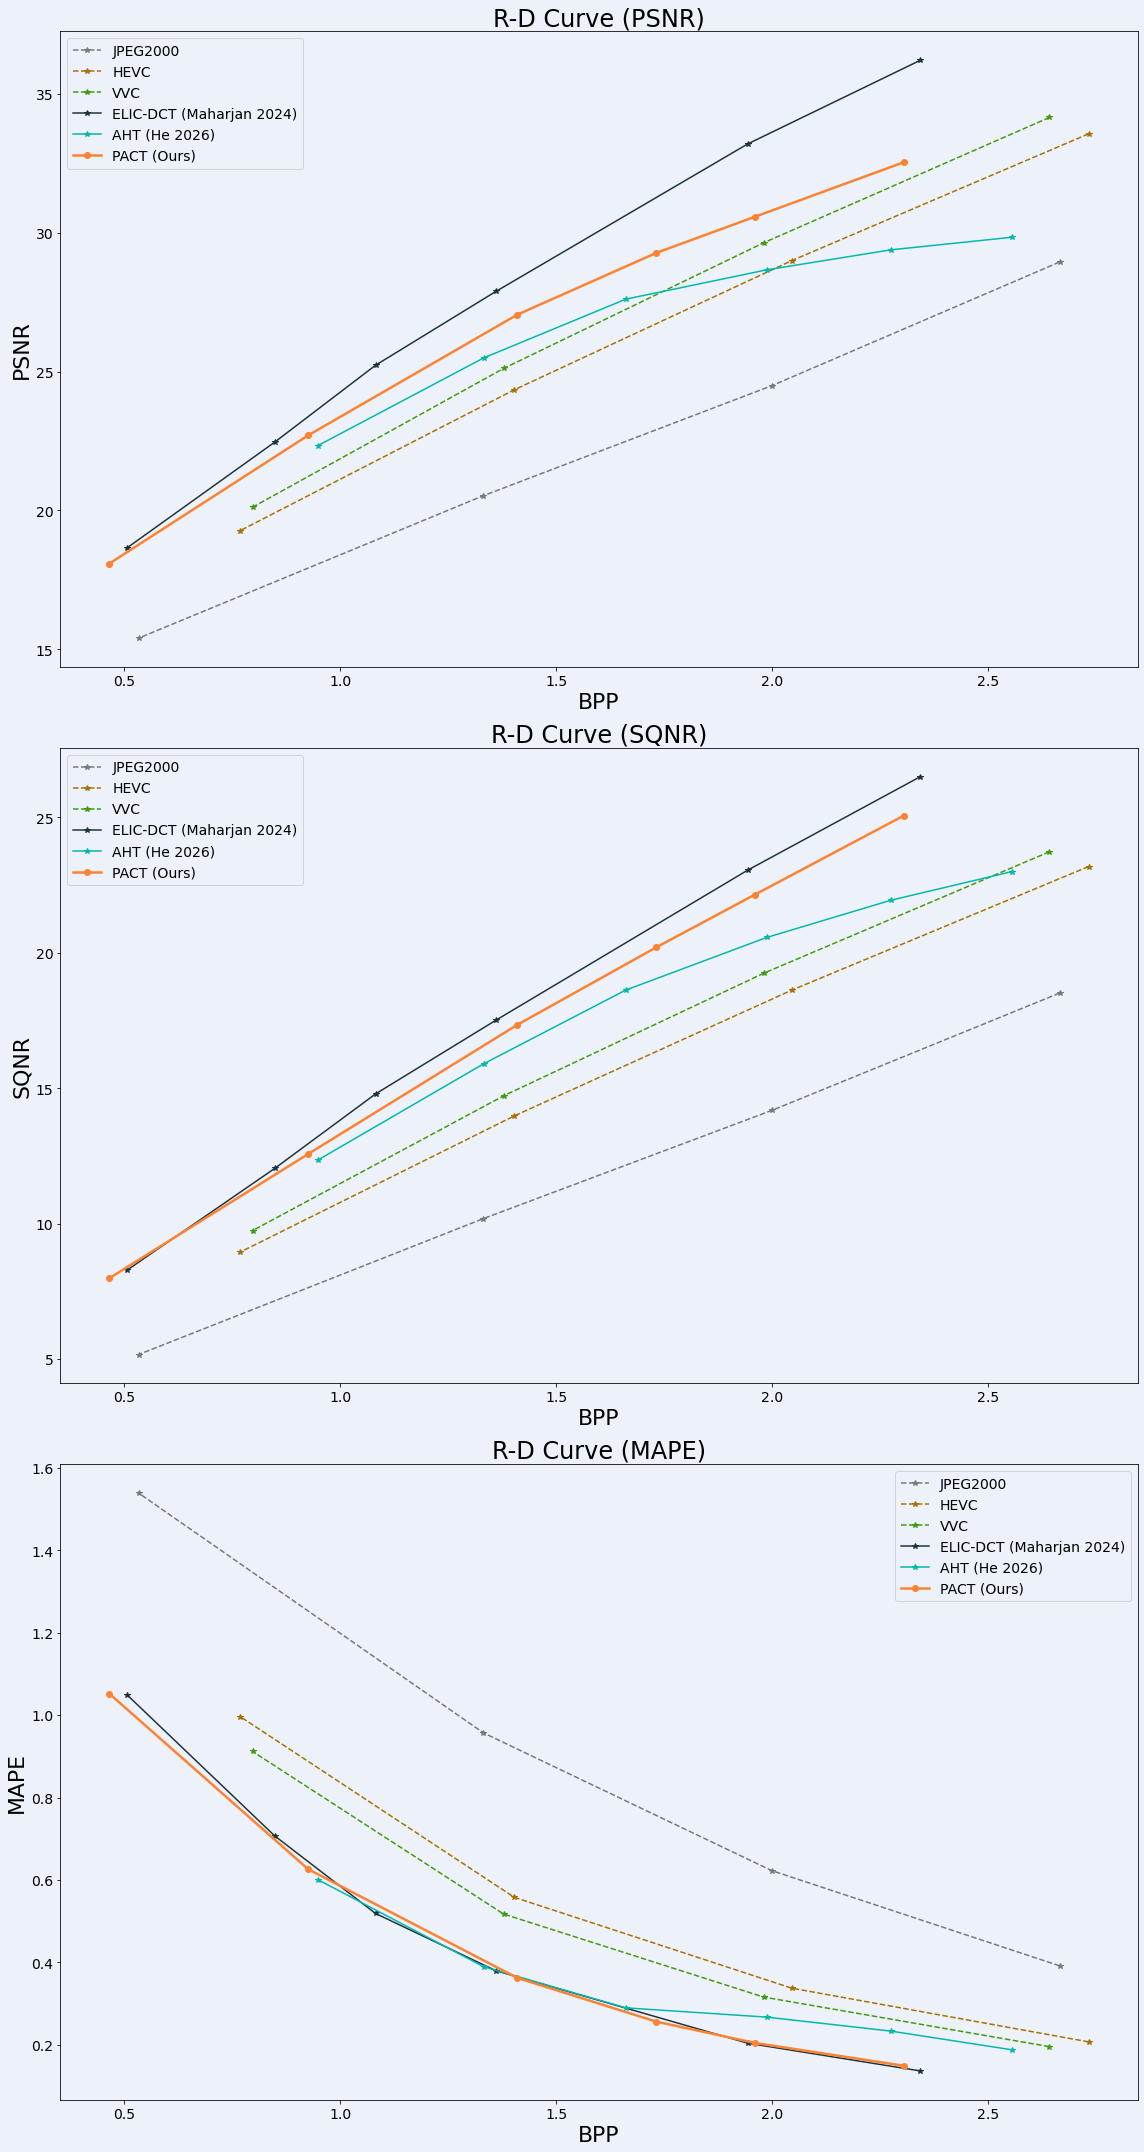

In [7]:
jpeg2000_hr_data = results_bench_df[(results_bench_df["codec"] == "JPEG2000") & (results_bench_df["dataset"] == "test")]
hevc_hr_data = results_bench_df[(results_bench_df["codec"] == "HM") & (results_bench_df["dataset"] == "test")]
vvc_hr_data = results_bench_df[(results_bench_df["codec"] == "VTM") & (results_bench_df["dataset"] == "test")]
pactiq_hr_data = results_highres_df[(results_highres_df["arch"] == "PACT") & (results_highres_df["model"] == "g8alpha1.0")]
pactamp_hr_data = results_highres_df[(results_highres_df["arch"] == "PACT") & (results_highres_df["model"] == "g8alpha0.01")]
aht_hr_data = results_highres_df[results_highres_df["arch"] == "AHT"]

rd_data = {
    "jpeg2000": {
        "bpp": jpeg2000_hr_data["bpp"].round(4).tolist(),
        "psnr": jpeg2000_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": jpeg2000_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": jpeg2000_hr_data["mae_phase"].round(4).tolist(),
        "color": "#787878",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
        "legend": "JPEG2000",
    },
    "hevc": {
        "bpp": hevc_hr_data["bpp"].round(4).tolist(),
        "psnr": hevc_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": hevc_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": hevc_hr_data["mae_phase"].round(4).tolist(),
        "color": "#A77002",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
        "legend": "HEVC",
    },
    "vvc": {
        "bpp": vvc_hr_data["bpp"].round(4).tolist(),
        "psnr": vvc_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": vvc_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": vvc_hr_data["mae_phase"].round(4).tolist(),
        "color": "#419A0E",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
        "legend": "VVC",
    },
    "elicdct": {
        "bpp":  [2.9640 , 2.7782 , 2.5324 , 2.3432 , 1.9434 , 1.3604 , 1.0817 , 0.8479 , 0.5069][3:],
        "psnr": [39.0820, 38.6299, 37.3533, 36.2189, 33.2039, 27.8906, 25.2319, 22.4584, 18.6599][3:],
        "sqnr": [30.6782, 29.6883, 27.9480, 26.5056, 23.0530, 17.5115, 14.7887, 12.0348, 8.2879][3:],
        "mape": [0.0833 , 0.0936 , 0.1150 , 0.1364 , 0.2037 , 0.3796 , 0.5186 , 0.7072 , 1.0487][3:],
        "color":"#1d323b",
        "marker": "*",
        "linestyle": "solid",
        "linewidth": 1.5,
        "legend": "ELIC-DCT (Maharjan 2024)",
    },
    "aht": {
        "bpp": aht_hr_data["bpp"].round(4).tolist(),
        "psnr": aht_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": aht_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": aht_hr_data["mae_phase"].round(4).tolist(),
        "color": "#01b8aa",
        "marker": "*",
        "linestyle": "solid",
        "linewidth": 1.5,
        "legend": "AHT (He 2026)",
    },
    # "pactiq": {
    #     "bpp": pactiq_hr_data["bpp"].round(4).tolist(),
    #     "psnr": pactiq_hr_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": pactiq_hr_data["sqnr_amp"].round(4).tolist(),
    #     "mape": pactiq_hr_data["mae_phase"].round(4).tolist(),
    #     "color": "#01b8aa",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    "pactamp": {
        "bpp": pactamp_hr_data["bpp"].round(4).tolist(),
        "psnr": pactamp_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": pactamp_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": pactamp_hr_data["mae_phase"].round(4).tolist(),
        "color": "#FC8333",
        "marker": "o",
        "linestyle": "solid",
        "linewidth": 2.5,
        "legend": "PACT (Ours)",
    },
}

# SQNR BD-Rate
print("SQNR BD-RATE")
for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    psnr_test = rd_data[model]["sqnr"]
    rate_anchor = rd_data["vvc"]["bpp"]
    psnr_anchor = rd_data["vvc"]["sqnr"]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor, 
        psnr_anchor, 
        rate_test, 
        psnr_test, 
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

# MAPE BD-Rate
print("\nMAPE BD-RATE")
for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    mape_test = [-x for x in rd_data[model]["mape"]]
    rate_anchor = rd_data["vvc"]["bpp"]
    mape_anchor = [-x for x in rd_data["vvc"]["mape"]]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor, 
        mape_anchor, 
        rate_test, 
        mape_test, 
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

# Make 3 subplots for PSNR, SQNR, and MAPE
fig, ax = plt.subplots(3, 1, figsize=(16, 30))
bg_color = "#edf1fa"

ax[0].set_title("R-D Curve (PSNR)", fontsize=24)
ax[1].set_title("R-D Curve (SQNR)", fontsize=24)
ax[2].set_title("R-D Curve (MAPE)", fontsize=24)

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    sqnr = rd_data[model]["sqnr"]
    mape = rd_data[model]["mape"]

    ax[0].plot(bpp, psnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])
    ax[1].plot(bpp, sqnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])
    ax[2].plot(bpp, mape, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])

ax[0].set_xlabel("BPP", fontsize=22)
ax[0].set_ylabel("PSNR", fontsize=22)
ax[0].legend([rd_data[key]["legend"] for key in rd_data.keys()], facecolor=bg_color)
ax[1].set_xlabel("BPP", fontsize=22)
ax[1].set_ylabel("SQNR", fontsize=22)
ax[1].legend([rd_data[key]["legend"] for key in rd_data.keys()], facecolor=bg_color)

# extent = ax[1].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
# fig.savefig("rd_sqnr.png", bbox_inches=extent)

ax[2].set_xlabel("BPP", fontsize=22)
ax[2].set_ylabel("MAPE", fontsize=22)
ax[2].legend([rd_data[key]["legend"] for key in rd_data.keys()], facecolor=bg_color)
fig.set_facecolor(bg_color)
ax[0].set_facecolor(bg_color)
ax[1].set_facecolor(bg_color)
ax[2].set_facecolor(bg_color)
plt.tight_layout()
plt.show()

### LR Data

SQNR BD-RATE
Model: jpeg2000 | BD-Rate: 51.40%
Model: hevc | BD-Rate: 7.55%
Model: vvc | BD-Rate: 0.00%
Model: elicdct | BD-Rate: -19.15%
Model: aht | BD-Rate: -12.29%
Model: pactamp | BD-Rate: -19.52%

MAPE BD-RATE
Model: jpeg2000 | BD-Rate: 58.31%
Model: hevc | BD-Rate: 7.17%
Model: vvc | BD-Rate: 0.00%
Model: elicdct | BD-Rate: -19.01%
Model: aht | BD-Rate: -21.81%
Model: pactamp | BD-Rate: -26.34%


/scratch/zb7df/envs/aht/lib/python3.8/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '70.17'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/scratch/zb7df/envs/aht/lib/python3.8/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '66.69'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/scratch/zb7df/envs/aht/lib/python3.8/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '70.25'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/scratch/zb7df/envs/aht/lib/python3.8/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '45.74'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(


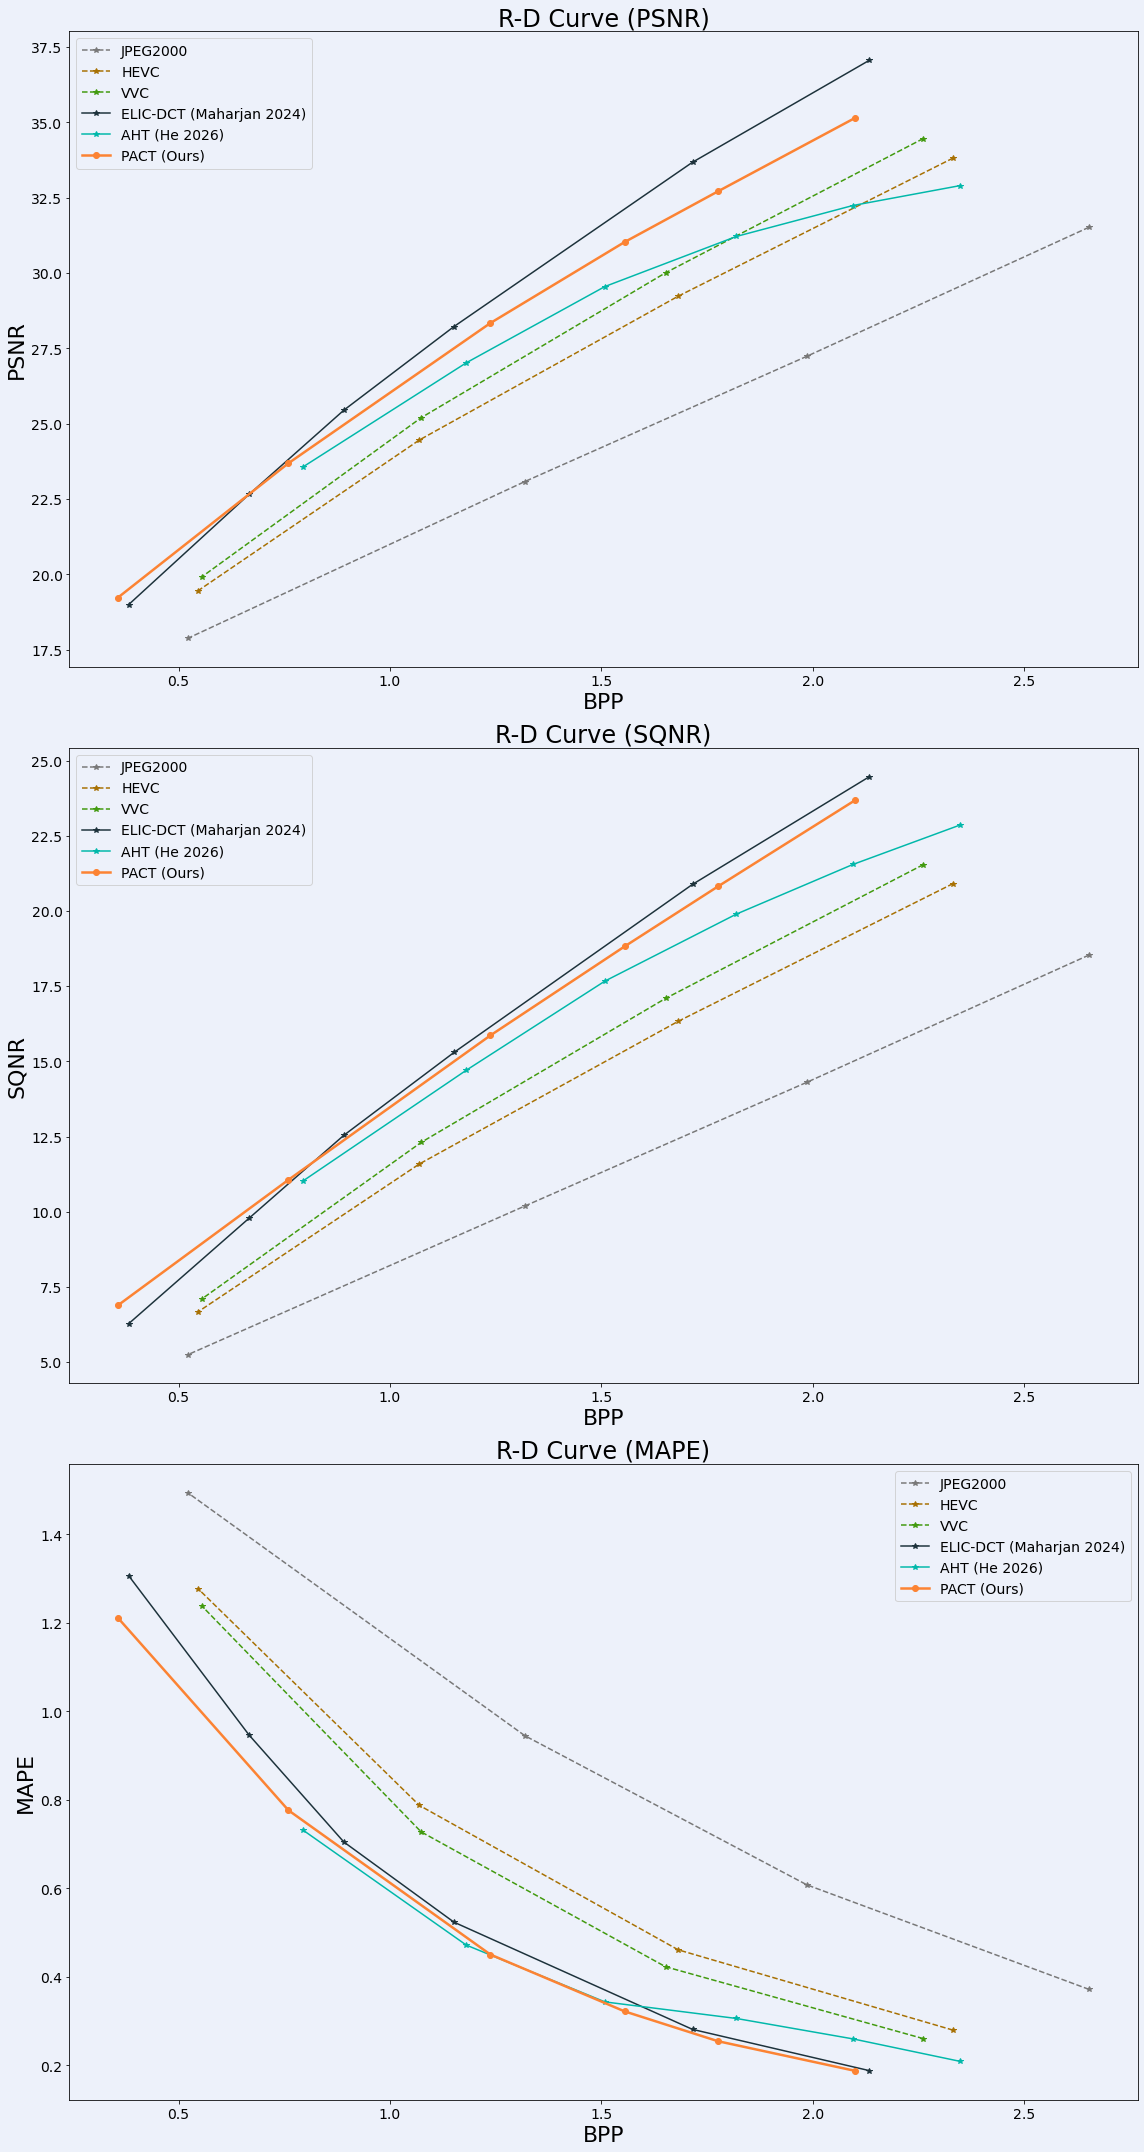

In [8]:
jpeg2000_lr_data = results_bench_df[(results_bench_df["codec"] == "JPEG2000") & (results_bench_df["dataset"] == "val")]
hevc_lr_data = results_bench_df[(results_bench_df["codec"] == "HM") & (results_bench_df["dataset"] == "val")]
vvc_lr_data = results_bench_df[(results_bench_df["codec"] == "VTM") & (results_bench_df["dataset"] == "val")]
pactamp_lr_data = results_df[(results_df["arch"] == "PACT") & (results_df["model"] == "g8alpha0.01")]
aht_lr_data = results_df[results_df["arch"] == "AHT"]

rd_data = {
    "jpeg2000": {
        "bpp": jpeg2000_lr_data["bpp"].round(4).tolist(),
        "psnr": jpeg2000_lr_data["psnr_amp"].round(4).tolist(),
        "sqnr": jpeg2000_lr_data["sqnr_amp"].round(4).tolist(),
        "mape": jpeg2000_lr_data["mae_phase"].round(4).tolist(),
        "color": "#787878",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
        "legend": "JPEG2000",
    },
    "hevc": {
        "bpp": hevc_lr_data["bpp"].round(4).tolist(),
        "psnr": hevc_lr_data["psnr_amp"].round(4).tolist(),
        "sqnr": hevc_lr_data["sqnr_amp"].round(4).tolist(),
        "mape": hevc_lr_data["mae_phase"].round(4).tolist(),
        "color": "#A77002",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
        "legend": "HEVC",
    },
    "vvc": {
        "bpp": vvc_lr_data["bpp"].round(4).tolist(),
        "psnr": vvc_lr_data["psnr_amp"].round(4).tolist(),
        "sqnr": vvc_lr_data["sqnr_amp"].round(4).tolist(),
        "mape": vvc_lr_data["mae_phase"].round(4).tolist(),
        "color": "#419A0E",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
        "legend": "VVC",
    },
    "elicdct": {
        "bpp":  [0.381772, 0.666746, 0.890905, 1.151270, 1.715433, 2.133557],
        "psnr": [18.988330, 22.650704, 25.444881, 28.219662, 33.674237, 37.057551],
        "sqnr": [6.275662, 9.784876, 12.543077, 15.296145, 20.885183, 24.465121],
        "mape": [1.306853, 0.946543, 0.704783, 0.523638, 0.281331, 0.188121],
        "color":"#1d323b",
        "marker": "*",
        "linestyle": "solid",
        "linewidth": 1.5,
        "legend": "ELIC-DCT (Maharjan 2024)",
    },
    "aht": {
        "bpp": aht_lr_data["bpp"].round(4).tolist(),
        "psnr": aht_lr_data["psnr_amp"].round(4).tolist(),
        "sqnr": aht_lr_data["sqnr_amp"].round(4).tolist(),
        "mape": aht_lr_data["mae_phase"].round(4).tolist(),
        "color": "#01b8aa",
        "marker": "*",
        "linestyle": "solid",
        "linewidth": 1.5,
        "legend": "AHT (He 2026)",
    },
    "pactamp": {
        "bpp": pactamp_lr_data["bpp"].round(4).tolist(),
        "psnr": pactamp_lr_data["psnr_amp"].round(4).tolist(),
        "sqnr": pactamp_lr_data["sqnr_amp"].round(4).tolist(),
        "mape": pactamp_lr_data["mae_phase"].round(4).tolist(),
        "color": "#FC8333",
        "marker": "o",
        "linestyle": "solid",
        "linewidth": 2.5,
        "legend": "PACT (Ours)",
    },
}

# SQNR BD-Rate
print("SQNR BD-RATE")
for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    psnr_test = rd_data[model]["sqnr"]
    rate_anchor = rd_data["vvc"]["bpp"]
    psnr_anchor = rd_data["vvc"]["sqnr"]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor, 
        psnr_anchor, 
        rate_test, 
        psnr_test, 
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

# MAPE BD-Rate
print("\nMAPE BD-RATE")
for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    mape_test = [-x for x in rd_data[model]["mape"]]
    rate_anchor = rd_data["vvc"]["bpp"]
    mape_anchor = [-x for x in rd_data["vvc"]["mape"]]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor, 
        mape_anchor, 
        rate_test, 
        mape_test, 
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

# Make 3 subplots for PSNR, SQNR, and MAPE
fig, ax = plt.subplots(3, 1, figsize=(16, 30))
bg_color = "#edf1fa"

ax[0].set_title("R-D Curve (PSNR)", fontsize=24)
ax[1].set_title("R-D Curve (SQNR)", fontsize=24)
ax[2].set_title("R-D Curve (MAPE)", fontsize=24)

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    sqnr = rd_data[model]["sqnr"]
    mape = rd_data[model]["mape"]

    ax[0].plot(bpp, psnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])
    ax[1].plot(bpp, sqnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])
    ax[2].plot(bpp, mape, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])

ax[0].set_xlabel("BPP", fontsize=22)
ax[0].set_ylabel("PSNR", fontsize=22)
ax[0].legend([rd_data[key]["legend"] for key in rd_data.keys()], facecolor=bg_color)
ax[1].set_xlabel("BPP", fontsize=22)
ax[1].set_ylabel("SQNR", fontsize=22)
ax[1].legend([rd_data[key]["legend"] for key in rd_data.keys()], facecolor=bg_color)

# extent = ax[1].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
# fig.savefig("rd_sqnr.png", bbox_inches=extent)

ax[2].set_xlabel("BPP", fontsize=22)
ax[2].set_ylabel("MAPE", fontsize=22)
ax[2].legend([rd_data[key]["legend"] for key in rd_data.keys()], facecolor=bg_color)
fig.set_facecolor(bg_color)
ax[0].set_facecolor(bg_color)
ax[1].set_facecolor(bg_color)
ax[2].set_facecolor(bg_color)
plt.tight_layout()
plt.show()

### Data from Maharjan 2024 (ELIC-DCT)

In [ ]:
# rd_data = {
#     # JPEG2000 (lowest BPP not shown in paper)
#     "jpeg2000": {
#         "bpp":  [2.6647 , 1.999  , 1.5992 , 0.9996 , 0.5323],
#         "psnr": [28.925 , 24.4725, 22.2939, 18.6632, 15.3867],
#         "sqnr": [18.4845, 14.1511, 11.9136, 8.3596 , 5.1653],
#         "mape": [0.3918 , 0.6234 , 0.8121 , 1.1672 , 1.5330],
#         "color":"#01b8aa",
#         "marker": "^",
#         "linestyle": "dashed",
#     },
#     # HEVC
#     "hevc": {
#         "bpp":  [2.8405 , 2.5788 , 1.9839 , 1.4525 , 0.9826 ],
#         "psnr": [33.1111, 31.5369, 27.8776, 24.1401, 20.6104],
#         "sqnr": [22.6497, 21.0718, 17.4426, 13.7223, 10.2396],
#         "mape": [0.2195 , 0.2593 , 0.3812 , 0.5717 , 0.8370],
#         "color":"#003f5c",
#         "marker": "d",
#         "linestyle": "dashed",
#     },
#     # VVC (lowest BPP not shown in paper)
#     "vvc": {
#         "bpp":  [2.8008 , 2.5111 , 1.98   , 1.4989 , 0.9148 , 0.5456 ],
#         "psnr": [34.4543, 32.8780, 29.3566, 25.9315, 21.1603, 17.3979],
#         "sqnr": [23.9722, 22.4221, 18.9250, 15.5249, 10.7797, 7.0912],
#         "mape": [0.1867 , 0.2199 , 0.3190 , 0.4632 , 0.7914 , 1.1828],
#         "color":"#9F2B68",
#         "marker": "s",
#         "linestyle": "dashed",
#     },
#     # LearnedIQ (Maharjan 2023)
#     "learnediq": {
#         "bpp":  [2.8405 , 2.5788 , 1.9839 , 1.4525 , 0.9826 ],
#         "psnr": [34.3395, 32.9682, 29.4298, 25.3870, 21.5924],
#         "sqnr": [23.9356, 22.5431, 18.9904, 14.9526, 11.1809],
#         "mape": [0.1894 , 0.2232 , 0.3366 , 0.5202 , 0.7773],
#         "color":"#65AD5E",
#         "marker": "P",
#         "linestyle": "dashed",
#     },
#     # ELIC-DCT (Maharjan 2024)
#     "elicdct": {
#         "bpp":  [2.9640 , 2.7782 , 2.5324 , 2.3432 , 1.9434 , 1.3604 ],
#         "psnr": [39.0820, 38.6299, 37.3533, 36.2189, 33.2039, 27.8906],
#         "sqnr": [30.6782, 29.6883, 27.9480, 26.5056, 23.0530, 17.5115],
#         "mape": [0.0833 , 0.0936 , 0.1150 , 0.1364 , 0.2037 , 0.3796 ],
#         "color":"#ed553b",
#         "marker": "*",
#         "linestyle": "dashed",
#     },
#     # VVC (test run)
#     "vvc_test": {
#         "bpp":  [2.6424026489257812, 1.9804115295410156, 1.3783226013183594, 0.7968597412109375],
#         "psnr": [34.16133261181379, 29.643372360672803, 25.11676455873928, 20.116903173267527],
#         "sqnr": [0, 0, 0, 0],
#         "mape": [0, 0, 0, 0],
#         "color":"#66FF00",
#         "marker": "*",
#         "linestyle": "dashed",
#     },
#     # HEVC (test run)
#     "hevc_test": {
#         "bpp":  [2.7330551147460938, 2.0455093383789062, 1.4030494689941406, 0.7681961059570312],
#         "psnr": [33.56907014143184, 29.000359417029383, 24.347895303037514, 19.27389649617288],
#         "sqnr": [0, 0, 0, 0],
#         "mape": [0, 0, 0, 0],
#         "color":"#FF0000",
#         "marker": "*",
#         "linestyle": "dashed",
#     },
# }

# Analysis of Tokens

Normalized SAR Image:
-- Shape: torch.Size([1, 2, 256, 256]) | Range: [0.0000, 1.0000]
DCT Tokens:
-- Shape: torch.Size([1, 32, 64, 64]) | Range: [-1.1140, 2.9335]


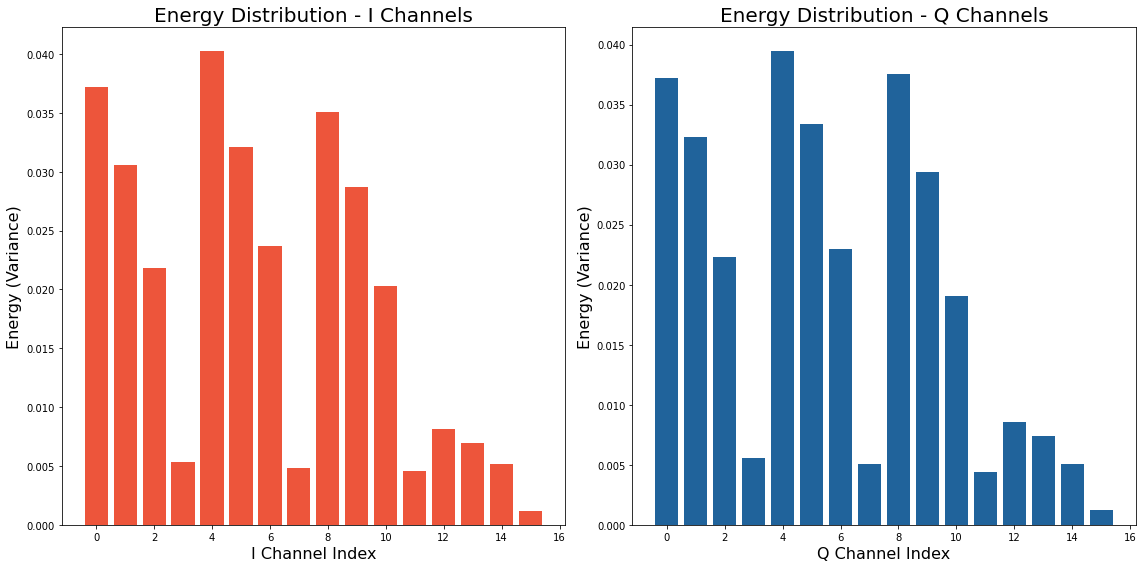

In [30]:
from src.utils.dct import ImageDCT
from test import load_image

inp = "/scratch/zb7df/data/NGA/multi_pol/validation/gt_HH/0.npy"
block = 4

img = load_image(inp)
dct_util = ImageDCT(block_size=block)
dc_ac = dct_util.dct_2d(img)

print("Normalized SAR Image:")
print(f"-- Shape: {img.shape} | Range: [{img.min().item():.4f}, {img.max().item():.4f}]")
print("DCT Tokens:")
print(f"-- Shape: {dc_ac.shape} | Range: [{dc_ac.min().item():.4f}, {dc_ac.max().item():.4f}]")

# Take variance across spatial dimensions for each channel
channel_energy = dc_ac.var(dim=[2, 3])
channel_energy_I = channel_energy[:, :16]
channel_energy_Q = channel_energy[:, 16:]

# # Plot energy distribution across I channels
# plt.figure(figsize=(12, 6))
# plt.bar(range(channel_energy.shape[1]), channel_energy[0].cpu().numpy(), color="#ed553b")
# plt.xlabel("Channel Index", fontsize=16)
# plt.ylabel("Energy (Variance)", fontsize=16)
# plt.title("Energy Distribution Across DCT Channels", fontsize=24)
# plt.tight_layout()
# plt.show()

# Plot energy distributions for I and Q channels in subplots
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.bar(range(channel_energy_I.shape[1]), channel_energy_I[0].cpu().numpy(), color="#ed553b")
plt.xlabel("I Channel Index", fontsize=16)
plt.ylabel("Energy (Variance)", fontsize=16)
plt.title("Energy Distribution - I Channels", fontsize=20)
plt.subplot(1, 2, 2)
plt.bar(range(channel_energy_Q.shape[1]), channel_energy_Q[0].cpu().numpy(), color="#20639b")
plt.xlabel("Q Channel Index", fontsize=16)
plt.ylabel("Energy (Variance)", fontsize=16)
plt.title("Energy Distribution - Q Channels", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
k = 8
in_channels = 32
out_channels = 64

energy_df = pd.DataFrame({"channel": list(range(channel_energy.shape[1])), "energy": channel_energy.flatten()})
energy_df = energy_df.sort_values(by="energy", ascending=False).reset_index(drop=True)
energy_df["energy_prop"] = energy_df["energy"] / energy_df["energy"].sum()

conn = k * out_channels
conn_adj = conn - (k * in_channels)
energy_df["connections"] = (energy_df["energy_prop"] * conn)
energy_df["connections_int"] = energy_df["connections"].round().astype(int)
energy_df["connections_adj"] = (energy_df["energy_prop"] * conn_adj) + k
energy_df["connections_adj_int"] = energy_df["connections_adj"].round().astype(int)
energy_df.loc[0, "connections_adj_int"] = energy_df.loc[0, "connections_adj_int"] - (energy_df["connections_adj_int"].sum() - conn)

print(energy_df["connections_int"].sum())
print(energy_df["connections_adj_int"].sum())
energy_df

# min 4

512
512


,channel,energy,energy_prop,connections,connections_int,connections_adj,connections_adj_int
0,4,0.040253,0.065273,33.419853,33,24.709927,26
1,20,0.039462,0.063991,32.763226,33,24.381613,24
2,24,0.037534,0.060865,31.162998,31,23.581499,24
3,16,0.037230,0.060371,30.909962,31,23.454981,23
4,0,0.037220,0.060355,30.901646,31,23.450823,23
5,8,0.035111,0.056935,29.150715,29,22.575357,23
6,21,0.033365,0.054105,27.701591,28,21.850796,22
7,17,0.032327,0.052420,26.839205,27,21.419601,21
8,5,0.032079,0.052019,26.633577,27,21.316788,21
9,1,0.030548,0.049536,25.362358,25,20.681179,21


## Plot Amp Image

torch.Size([1024, 1024])


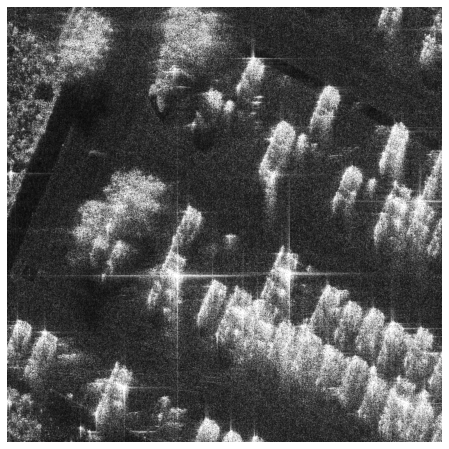

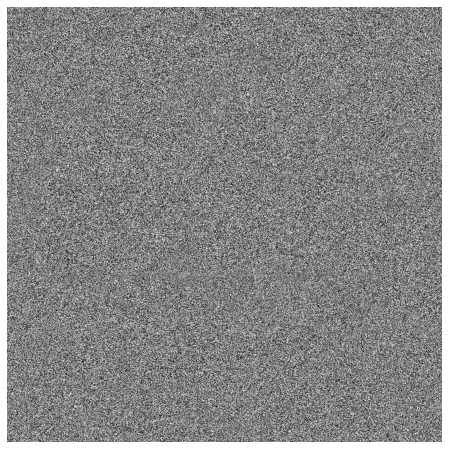

torch.Size([1024, 1024])


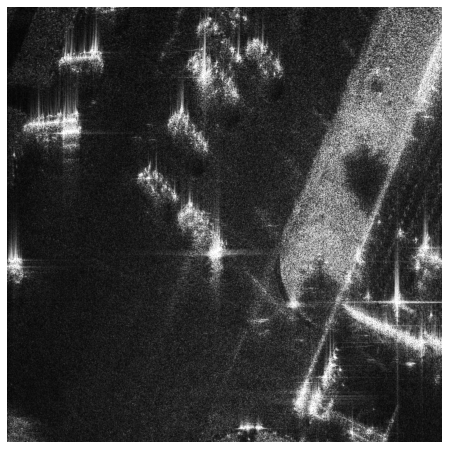

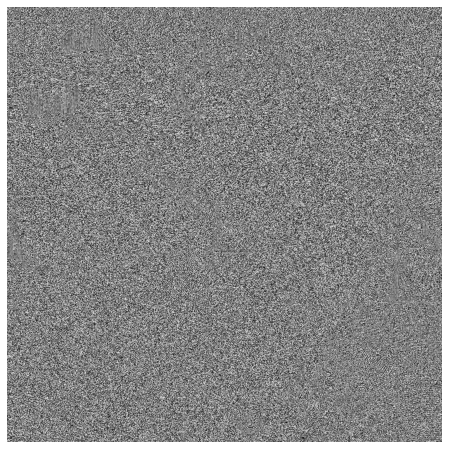

In [6]:
# Convert I/Q into Amplitude and display
import torch


def load_image(path):
    img_np = np.load(path)
    img_tensor = torch.from_numpy(img_np).float()
    return img_tensor


def iq_to_ap(iq):
    I = iq[:, :, 0]
    Q = iq[:, :, 1]
    amp = torch.sqrt(I**2 + Q**2)
    phase = torch.atan2(Q, I)
    return amp, phase


paths = ["/scratch/zb7df/data/NGA/multi_pol/test/gt_HH/0.npy",
         "/scratch/zb7df/data/NGA/multi_pol/test2/gt_HH/0.npy"]
for path in paths:
    img = load_image(path)
    amp, phase = iq_to_ap(img)
    print(amp.shape)

    plt.figure(figsize=(8, 8))
    plt.imshow(amp.cpu().numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(8, 8))
    plt.imshow(phase.cpu().numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

In [2]:
import shutil
from pathlib import Path

base_src = Path("/scratch/zb7df/data/NGA/multi_pol/train/")
base_dst = Path("/scratch/zb7df/data/NGA/multi_pol/train_val/")

for pol in ["gt_HH", "gt_HV", "gt_VH", "gt_VV"]:
    src = base_src / pol
    dst = base_dst / pol
    dst.mkdir(parents=True, exist_ok=True)
    for f in src.glob("*.npy"):
        if int(f.stem) % 10 == 0:
            shutil.move(f, dst / f.name)

In [37]:
logdir = "/scratch/zb7df/checkpoints/AHT_DCT"
dest = "/home/zb7df/dev/AHT_DCT/training_logs"

for folder in os.listdir(logdir):
    folder_path = os.path.join(logdir, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.startswith("events.out.tfevents"):
                src_file = os.path.join(folder_path, file)
                os.makedirs(os.path.join(dest, folder), exist_ok=True)
                dest_file = os.path.join(dest, f"{folder}/{file}")
                shutil.copy(src_file, dest_file)
                print(f"Copied {src_file} to {dest_file}")

Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT-exp2_lmbda0.025_20260127/events.out.tfevents.1769494055.kc-sse-ml-rn04.329343.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT-exp2_lmbda0.025_20260127/events.out.tfevents.1769494055.kc-sse-ml-rn04.329343.0
Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454850.kc-sse-ml-rn04.4054197.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454850.kc-sse-ml-rn04.4054197.0
Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454492.kc-sse-ml-rn04.4050119.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454492.kc-sse-ml-rn04.4050119.0
Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT_uneven_lmbda0.0067_20260128/events.out.tfevents.1769661596.kc-sse-ml-rn04.1082873.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT_uneven_lmbda0.0067_20260128/events.out.tfevents.1769

In [ ]:
# orig = (x * 10000) - 5000
# orig = torch.sqrt(torch.sum(orig ** 2, dim=1, keepdim=True))
# orig_amp_db = 20 * torch.log10(orig_amp + 1e-6)
# orig = orig.squeeze().cpu().numpy()
# vmin, vmax = np.percentile(orig_amp, [0, 100])
# print(orig_amp.shape)
# plt.imshow(orig_amp, cmap='gray', vmin=vmin, vmax=vmax)
# plt.show()